In [1]:
# !pip install langgraph
# !pip install langchain
# !pip install pygame
# #dbutils.library.restartPython()

In [2]:
import os
import mlflow
import subprocess

from typing import Callable
from dataclasses import dataclass
from typing import TypedDict, Annotated, List
import operator

from pathlib import Path
from dotenv import load_dotenv

from langchain_openai import AzureChatOpenAI
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

d:\lums-python-programming\databricks-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
curr_dir = Path.cwd()
target_env_path = curr_dir.parent / ".env"
#target_env_path = curr_dir / ".env"

success = load_dotenv(target_env_path, override=True)

print("AZURE_OPENAI_API_VERSION:", "SET" if os.getenv("AZURE_OPENAI_API_VERSION") else "NOT SET")
print("AZURE_OPENAI_API_KEY:", "SET" if os.getenv("AZURE_OPENAI_API_KEY") else "NOT SET")
print("AZURE_OPENAI_ENDPOINT:", "SET" if os.getenv("AZURE_OPENAI_ENDPOINT") else "NOT SET")
print("DATABRICKS_HOST:", "SET" if os.getenv("DATABRICKS_HOST") else "NOT SET")
print("DATABRICKS_TOKEN:", "SET" if os.getenv("DATABRICKS_TOKEN") else "NOT SET")

AZURE_OPENAI_API_VERSION: SET
AZURE_OPENAI_API_KEY: SET
AZURE_OPENAI_ENDPOINT: SET
DATABRICKS_HOST: SET
DATABRICKS_TOKEN: SET


## Task 1: Initializing System Memory and State Management [10 marks]

In [4]:
class GameState(TypedDict):
    director_messages: Annotated[list, add_messages]
    architect_messages: Annotated[list, add_messages]
    engineer_code: Annotated[list, add_messages]
    qa_feedback: Annotated[list, add_messages]
    current_actor: str
    iteration: int
    iteration_score: Annotated[list, operator.add]
    file_saved: bool

## Task 2: Implement Agent Nodes [40 marks]

### Subtask 2.1: Director and Architect Nodes

In [5]:
llm = AzureChatOpenAI(
    azure_endpoint=os.environ.get("AZURE_OPENAI_ENDPOINT"),
    azure_deployment=os.environ.get("AZURE_OPENAI_CHAT_DEPLOYMENT"), 
    api_version=os.environ.get("AZURE_OPENAI_API_VERSION"), 
    temperature=0.0
)

In [6]:
def director_node(state: GameState):
    director_msg = input("Awaiting Director Prompt: ")
    return {
        "director_messages": [HumanMessage(content=director_msg)], 
        "current_actor": "architect" 
    }


def architect_node(state: GameState):
    print(f"\n========== ITERATION {state.get('iteration', 0)} ==========")
    
    director_prompt = state.get("director_messages", [""])[-1].content

    #Including QA feedback, in case of iteration
    qa_context = ""
    if state.get("qa_feedback"):
        qa_context = f"\n\nPrevious QA feedback to address:\n{state['qa_feedback'][-1].content}"


    architect_system_prompt = """
        `Role:` You are a software architect. 
        `Task:` Given a game idea, produce a clear, structured technical design plan that an engineer can implement in Python using pygame.
        `Include:` game loop structure, key classes needed, controls, jump mechanics, and a score tracker.
    """

    architect_user_message = f"""
        Design a Python pygame game: 
        {director_prompt}
        {qa_context}
    """

    response = llm.invoke([
        AIMessage(content=architect_system_prompt),
        HumanMessage(content=architect_user_message)
    ])
    
    return {
        "architect_messages": [AIMessage(content=response.content)], 
        "current_actor": "engineer"
    }

### Subtask 2.2: Engineer Node

In [7]:
def engineer_node(state: GameState):
    architect_message = state.get("architect_messages", [""])[-1].content
    prev_code = state.get("engineer_code", [""])[-1].content if state.get("engineer_code") else ""
    qa_messages = state.get("qa_feedback", [""])[-1].content if state.get("qa_feedback") else ""

    eng_system_prompt = """
        `Role:` You are an expert Python game developer using pygame.
        `Task:` Write complete, runnable Python code. Return ONLY the raw Python code with. Make sure the game is easy and fun to play for the user as well.
        `Constraints:` No markdown fences, no ``` blocks, no explanation. Just pure Python.
    """

    eng_user_message = f"""
        Architect's design plan: {architect_message}\n
        Previous code (empty on first run): {prev_code}\n
        QA feedback to fix (empty on first run): {qa_messages}\n
        Write the complete, improved Python pygame Dino Runner game code.
        """

    response = llm.invoke([
        AIMessage(content=eng_system_prompt),
        HumanMessage(content=eng_user_message)
    ])
    
    return {
        "engineer_code": [AIMessage(content=response.content)],
        "current_actor": "file_writer",
        "iteration": state.get("iteration", 0) + 1
    }


### Subtask 2.3: File I/O and Execution Nodes

In [8]:
def file_writer(state: GameState):
    code = state.get("engineer_code")[-1].content

    # Making absolutely sure to strip any markdown fences
    if code.startswith("```"):
        code = "\n".join(code.split("\n")[1:])   # remove first line (```python)
    if code.endswith("```"):
        code = "\n".join(code.split("\n")[:-1])  # remove last line (```)

    with open("EC_dino_runner.py", "w", encoding="utf-8") as f:
        f.write(code)

    print(code[:500])
    print("\n[File saved: EC_dino_runner.py]")
    return {
        "file_saved": True,
        "current_actor": "run_code"
    }


def run_code(state: GameState):
    print("\n===== CODE EXECUTION =====")
    choice = input("Run the generated game? (y/n): ").strip().lower()
    if choice == "y":
        try:
            result = subprocess.run(
                ["python", "EC_dino_runner.py"], 
                capture_output=True, 
                text=True, 
                timeout=40
            )
            output = result.stdout + result.stderr
            print(output if output else "[No output / Game ran and closed normally]")

        except subprocess.TimeoutExpired:
            output = "Process timed out after 40 seconds"
            print(output)

        except Exception as e:
            print(f"Execution failed: {e}")

    return {
        "current_actor": "qa",
        "qa_feedback": [HumanMessage(content=f"[RUN OUTPUT]\n{output}")]
    }

### Subtask 2.4: QA and Scorer Nodes

# Bonus Task

In [9]:
class QA_Subgraph_State(TypedDict):
    engineer_code: str
    run_output: str
    design_requirements: str
    syntax_checker_feedback: str
    logic_tester_feedback: str
    performance_auditor_feedback: str
    qa_feedback: Annotated[list, add_messages] # Passed back to GameState

def syntax_checker_node(state: QA_Subgraph_State):
    code = state.get("engineer_code", "No code captured.")
    run_output = state.get("run_output", "No output captured.")

    syntax_system_prompt = """ 
        `Role:` You are a QA engineer specialised in syntax checking.\n
        `Task:` Check the provided Python code for any syntax errors, import errors, indentation issues. 
        If errors are found, list them clearly. If no syntax errors are present, confirm that the code is syntactically correct.
    """
    syntax_user_prompt = f""" 
        Code to check: {code}\n
        Execution output/errors: {run_output} \n
    """

    response = llm.invoke([
        AIMessage(content=syntax_system_prompt),
        HumanMessage(content=syntax_user_prompt)
    ])
    syntax_checker_feedback = response.content
    return {"syntax_checker_feedback": syntax_checker_feedback}


def logic_tester_node(state: QA_Subgraph_State):
    code = state.get("engineer_code", "No code captured.")
    run_output = state.get("run_output", "No output captured.")
    design_requirements = state.get("design_requirements", "No design requirements captured.")

    logic_system_prompt = """ 
        `Role:` You are a QA engineer specialised in logic testing.\n
        `Task:` Analyze the provided Python code for any logical errors or bugs that could affect the specified design requirements. 
        - Focus on jump mechanics, obstacle behavior, and score tracking. 
        - Ensure all the design requirements are met based on the provided code and execution output.
        - List any issues found with specific line references if possible.
    """

    logic_user_prompt = f""" 
        Code to analyze: {code}\n
        Design requirements to meet: {design_requirements}\n
        Execution output/errors: {run_output} \n
    """

    response = llm.invoke([
        AIMessage(content=logic_system_prompt),
        HumanMessage(content=logic_user_prompt)
    ])
    logic_tester_feedback = response.content
    return {"logic_tester_feedback": logic_tester_feedback}


def performance_auditor_node(state: QA_Subgraph_State):
    code = state.get("engineer_code", "No code captured.")
    syntax_feedback = state.get("syntax_checker_feedback", "No syntax report.")
    logic_feedback = state.get("logic_tester_feedback", "No logic report.")

    performance_system_prompt = f"""
        `Role:` You are a QA engineer specialised in performance auditing.\n
        `Task:` Analyze the provided Python pygame code for performance issues such as:
        - Inefficient loops or rendering that could cause frame rate drops
        - Memory leaks or objects not being cleaned up
        - Missing clock/FPS cap (game running too fast/slow)
        - Any other bottlenecks that would hurt gameplay smoothness
        List issues clearly with suggested fixes.
    """
    performance_user_prompt = f"""
        Code to audit: {code}
    """

    response = llm.invoke([
        AIMessage(content=performance_system_prompt),
        HumanMessage(content=performance_user_prompt)
    ])
    performance_auditor_feedback = response.content

    combined_report = f"""
    ========== QA SUBGRAPH REPORT ==========

    --- SYNTAX CHECKER ---
    {syntax_feedback}

    --- LOGIC TESTER ---
    {logic_feedback}

    --- PERFORMANCE AUDITOR ---
    {performance_auditor_feedback}

    ========================================
    """

    return {
        "performance_auditor_feedback": performance_auditor_feedback,
        "qa_feedback": [AIMessage(content=combined_report)]  # this flows back to parent
    }


qa_workflow = StateGraph(QA_Subgraph_State)
qa_workflow.add_node("syntax_checker", syntax_checker_node)
qa_workflow.add_node("logic_tester", logic_tester_node)
qa_workflow.add_node("performance_auditor", performance_auditor_node)

qa_workflow.set_entry_point("syntax_checker")
qa_workflow.add_edge("syntax_checker", "logic_tester")
qa_workflow.add_edge("logic_tester", "performance_auditor")
qa_workflow.add_edge("performance_auditor", END)  # flows back to main graph

qa_subgraph = qa_workflow.compile()


def qa_subgraph_node(state: GameState):
    run_output = state.get("qa_feedback", [""])[-1].content if state.get("qa_feedback") else "No output captured."
    code = state.get("engineer_code", [""])[-1].content if state.get("engineer_code") else "No code captured."

    design_requirements = """" 
        The Dino Runner game must have:
        1. Flying obstacles (Pterodactyls)
        2. Ground obstacles (Cacti)
        3. Accurate jumping and falling physics
        4. Logical placement of flying and ground obstacles to ensure engaging gameplay
        5. The dinosaur must be able to jump with correct user input mapping
        6. The dinosaur must be able to duck with correct user input mapping
        7. A functional high-score tracking system
    """
    
    result = qa_subgraph.invoke({
        "engineer_code":        code,
        "run_output":           run_output,
        "design_requirements":  design_requirements,
        "syntax_report":        "",
        "logic_report":         "",
        "performance_report":   "",
        "qa_feedback":          []
    }) 

    final_feedback = result["qa_feedback"][-1].content

    return {
        "qa_feedback": [AIMessage(content=final_feedback)],
        "current_actor": "scorer"
    }

In [10]:
def scorer_node(state: GameState):
    qa_feedback = state.get("qa_feedback", [""])[-1].content if state.get("qa_feedback") else "No QA feedback captured."

    scorer_system_prompt = """ 
        `Role:` You are a scorer. 
        `Task:` Based on the QA report, give a single integer score from 1 to 10 representing overall code quality and feature completeness.
        Score range: 1 = broken, 10 = perfect.
        `Constraint:` Reply with ONLY the number, nothing else.
    """

    scorer_user_message = f"""
        QA feedback to score: {qa_feedback}
    """

    response = llm.invoke([
        AIMessage(content=scorer_system_prompt),
        HumanMessage(content=scorer_user_message)
    ])

    # Parsing the score safely
    try:
        score = int("".join(filter(str.isdigit, response.content.strip())))
    except:
        score = 5   # default if parsing fails

    print(f"\n[SCORE FOR THIS ITERATION: {score}/10]")


    return {
        "iteration_score": [score],
        "current_actor": "human"
    }

In [11]:
def should_continue(state: GameState):
    scores = state.get("iteration_score", [])
    latest_score = scores[-1] if scores else 0
    print(f"\n[Latest score: {latest_score}/10]")
    print(f"[Scores so far: {scores}]")

    choice = input("Continue to next iteration? (y/n): ").strip().lower()
    if choice == "y":
        return "engineer"
    else:
        print("\n[Ending iterations. Final scores: ", scores, "]")
        return END

## Task 3: Create Graph Structure [20 marks]

In [12]:
workflow = StateGraph(GameState)

workflow.add_node("director", director_node)
workflow.add_node("architect", architect_node)
workflow.add_node("engineer", engineer_node)
workflow.add_node("file_writer", file_writer)
workflow.add_node("run_code", run_code)
workflow.add_node("qa", qa_subgraph_node)
workflow.add_node("scorer_node", scorer_node)

workflow.set_entry_point("director")

workflow.add_edge("director", "architect")
workflow.add_edge("architect", "engineer")
workflow.add_edge("engineer", "file_writer")
workflow.add_edge("file_writer", "run_code")
workflow.add_edge("run_code", "qa")
workflow.add_edge("qa", "scorer_node")

workflow.add_conditional_edges(
    "scorer_node", should_continue,    
    {
        "engineer": "engineer",   
        END: END                  
    }
)

memory = MemorySaver()
graph = workflow.compile(checkpointer=memory)

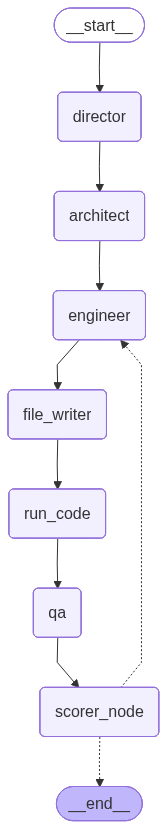

In [13]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

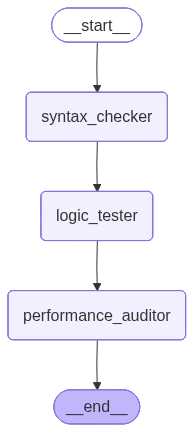

In [14]:
display(Image(qa_subgraph.get_graph().draw_mermaid_png()))

## Task 4: System Invocation [10 marks]

In [15]:
config = {"configurable": {"thread_id": "1"}}
print("--- STARTING WORKFLOW ---")

for event in graph.stream(
    {"iteration": 0, "file_saved": False},   # initial state
    config=config
    ):
    for node, value in event.items():
        print(f"\n===== {node.upper()} =====")
         # Print which actor is currently active if available
        if isinstance(value, dict) and value.get("current_actor"):
            print(f"  Next actor: {value['current_actor']}")

--- STARTING WORKFLOW ---

===== DIRECTOR =====
  Next actor: architect

========== ITERATION 0 ==========

===== ARCHITECT =====
  Next actor: engineer

===== ENGINEER =====
  Next actor: file_writer
import pygame
import random
import sys

pygame.init()

# Constants
SCREEN_WIDTH = 800
SCREEN_HEIGHT = 400
GROUND_HEIGHT = 350
FPS = 60

WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
DINO_COLOR = (83, 83, 83)
OBSTACLE_COLOR = (34, 139, 34)
GROUND_COLOR = (50, 50, 50)
BG_COLOR = (235, 235, 235)

FONT_NAME = pygame.font.get_default_font()

class Dino:
    def __init__(self):
        self.width = 44
        self.height = 47
        self.x = 50
        self.y = GROUND_HEIGHT - self.height
        self.ve

[File saved: EC_dino_runner.py]

===== FILE_WRITER =====
  Next actor: run_code

===== CODE EXECUTION =====
Traceback (most recent call last):
  File "d:\lums-python-programming\databricks-project\cs5305\PA4\EC\EC_dino_runner.py", line 1, in <module>
    import pygame
ModuleNotFoundError: No modu